# Installing and Using the bagelR Package

## Installing bagelR

The **bagelR** package can be installed via an interactive **R** session using the following code.

In [1]:
if(system.file(package = "bagelR") != "")
    {
      remove.packages("bagelR")
    }
library("remotes")
install_github("grosed/bagel/bagelR",force=TRUE)

Removing package from ‘/home/grosed/DASS/R-packages’
(as ‘lib’ is unspecified)

Using GitHub PAT from the git credential store.




Running `R CMD build`...



* checking for file ‘/tmp/RtmpAWlt4x/remotes145e511bdb2c82/grosed-bagel-62aaf57/bagelR/DESCRIPTION’ ... OK
* preparing ‘bagelR’:
* checking DESCRIPTION meta-information ... OK
* cleaning src
* installing the package to process help pages
* saving partial Rd database
* cleaning src
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘bagelR_1.3.0.tar.gz’


Installing package into ‘/home/grosed/DASS/R-packages’
(as ‘lib’ is unspecified)



## Check package version

In [2]:
packageVersion("bagelR")

[1] ‘1.3.0’

## Using bagelR - 1 : Detecting Change in Mean

#### Load the bagel package

In [3]:
library(bagelR)


Attaching package: ‘bagelR’


The following object is masked from ‘package:stats’:

    time




### Example 1 - no change

#### Define the feature vector function 

These functions for the **feature vector** and the **prior** correspeond to example 1 in "**Bagel : A Fast Baysian Online Changepoint Detection Algorithm for Linear Models**" *Fearnhead et al.*

In [4]:
feature_vector <- function(t,tau)
{
  if(tau == 0)
  {
    M <- matrix(c(0),nc=1,nr=1)       
    M[1,1] <- 1
    return(M)
  }
  else
  {
    M <- matrix(c(0),nc=1,nr=2)       
    M[1,1] <- 1
    if(t > tau)
    {
      M[2,1] <- 1
    }
    return(M)
  }
}

#### Define the prior function

In [5]:

prior <- function(t)
{
  mu1 <- 1;
  delta <- c(5,1)
  if(t == 1)
  {
    mu <- matrix(c(mu1),nc=1,nr=1)
    sigma <- delta[1]*diag(1)
    return(list("mu" = mu,"sigma" = sigma))
  }
  mu <- matrix(c(mu1,0),nc=1,nr=2)
  sigma <- diag(delta)
  return(list("mu" = mu,"sigma" = sigma))
}

#### Generate some data - no change

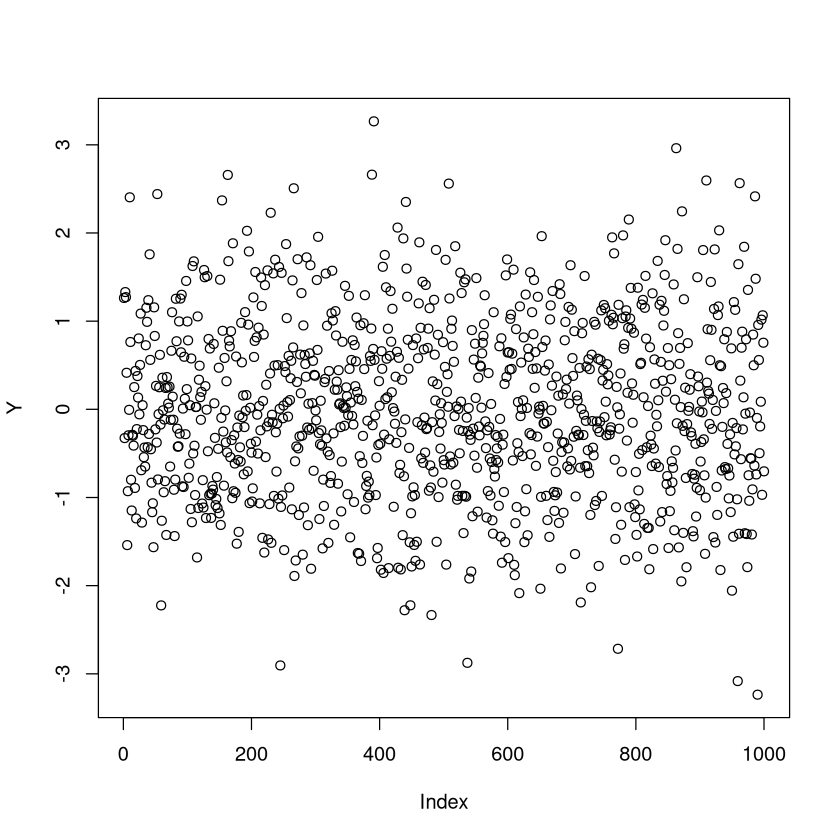

In [6]:
set.seed(0)
Y <- rnorm(1000,0,1)
plot(Y)

#### Set model parameters 

In [7]:
p <- 1.0;
p0 <- 0.9;
noise_sd <- 1.0;
max_particles <- 250
threshold <- 0.8

#### Offline analysis - known variance

In [8]:
results <- bagel_offline(feature_vector,prior,p0,p,max_particles,threshold,Y,noise_sd)

#### Check for a changepoint

In [9]:
changepoint(results)

[1] NA

#### Visualise weight at tau = 0

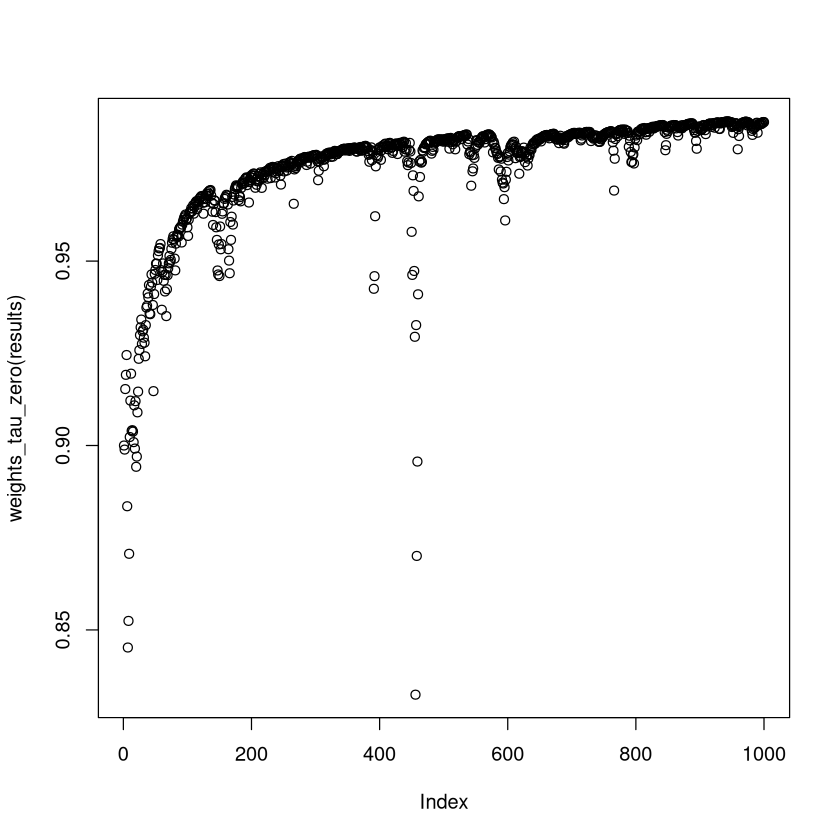

In [10]:
plot(weights_tau_zero(results))

#### Offline analysis - uknown variance

In [11]:
results <- bagel_offline(feature_vector,prior,p0,p,max_particles,threshold,Y)

#### Check for a changepoint

In [12]:
changepoint(results)

[1] NA

#### Visualise weight at tau = 0

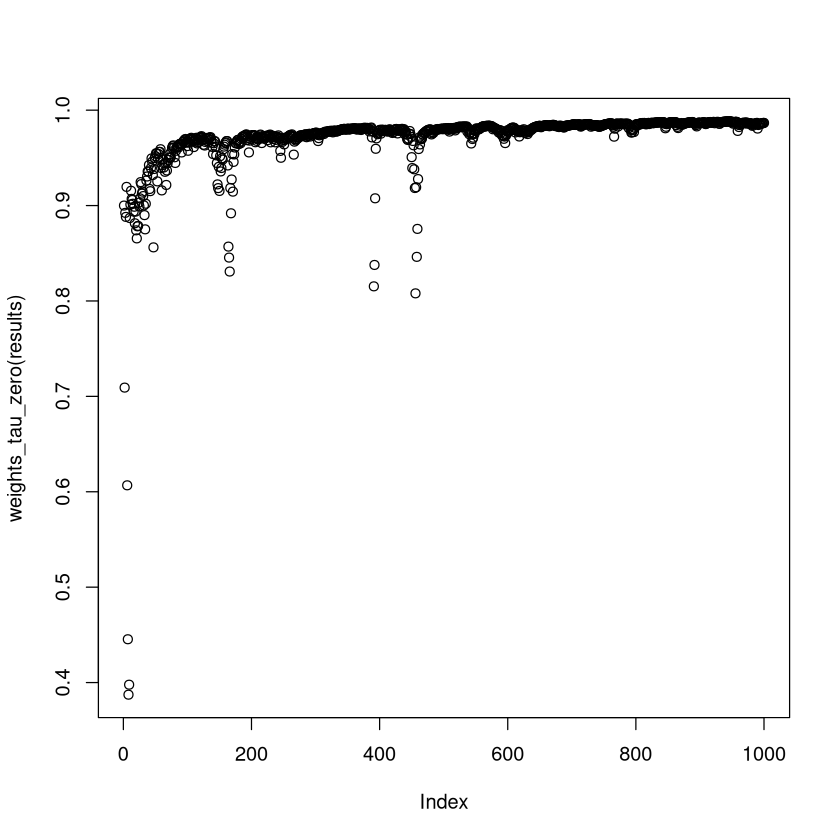

In [13]:
plot(weights_tau_zero(results))

### Example 2 - single change in mean

#### Generate some data - change at t = 501 

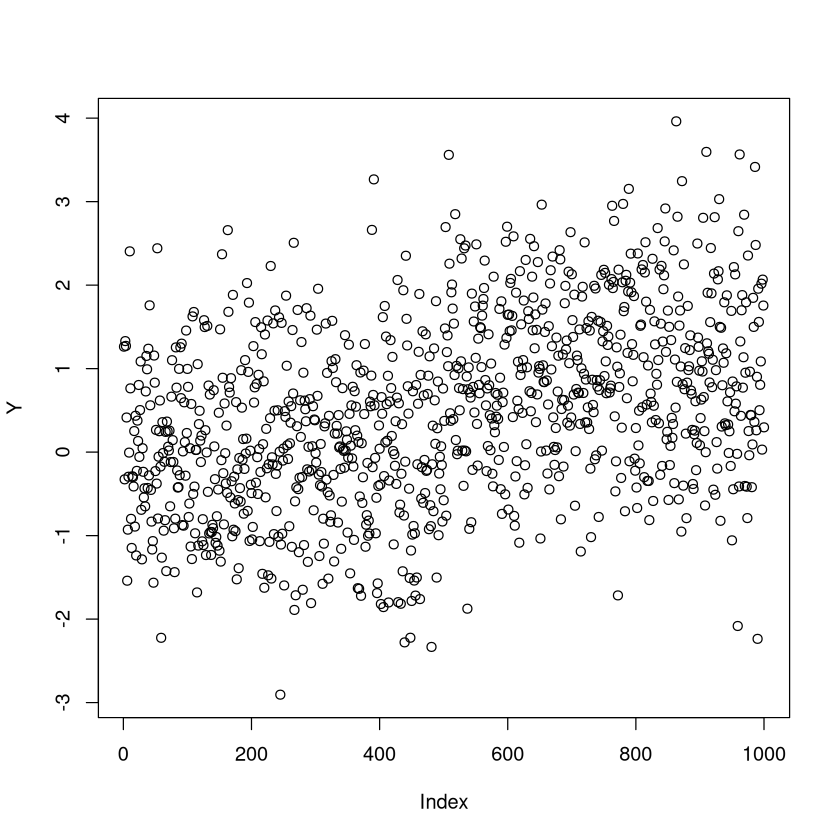

In [14]:
set.seed(0)
Y <- c(rnorm(500,0,1),rnorm(500,1,1))
plot(Y)

#### Offline analysis - known variance

In [15]:
results <- bagel_offline(feature_vector,prior,p0,p,max_particles,threshold,Y,noise_sd)

#### Check for a changepoint

In [16]:
changepoint(results)

$location
[1] 501

$detected
[1] 513

#### Visualise weight at tau = 0

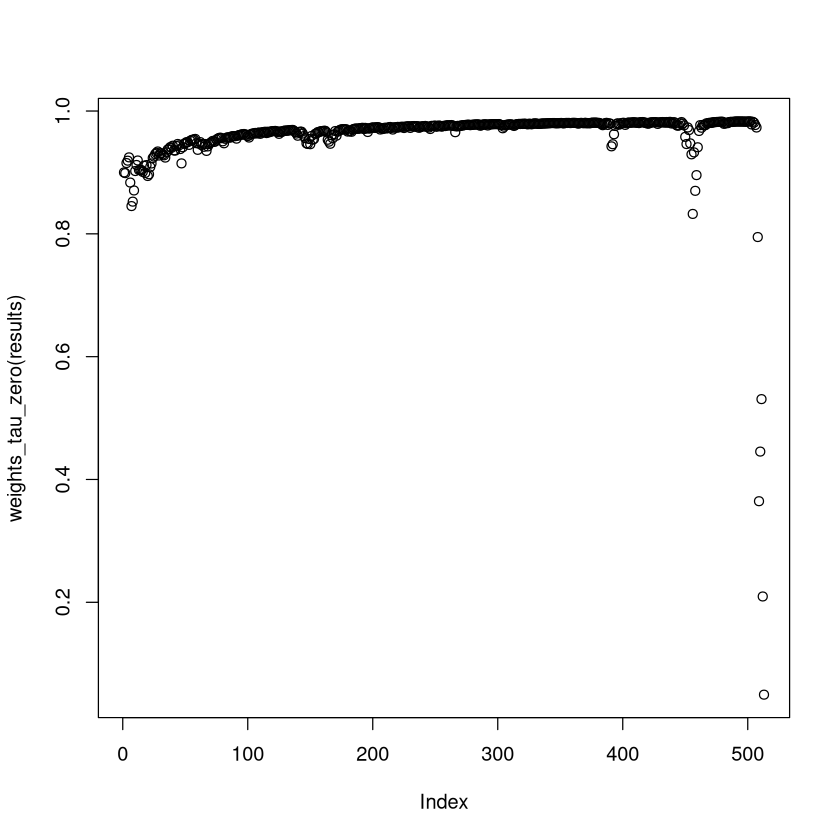

In [17]:
plot(weights_tau_zero(results))

#### Plot weights in region of changepoint

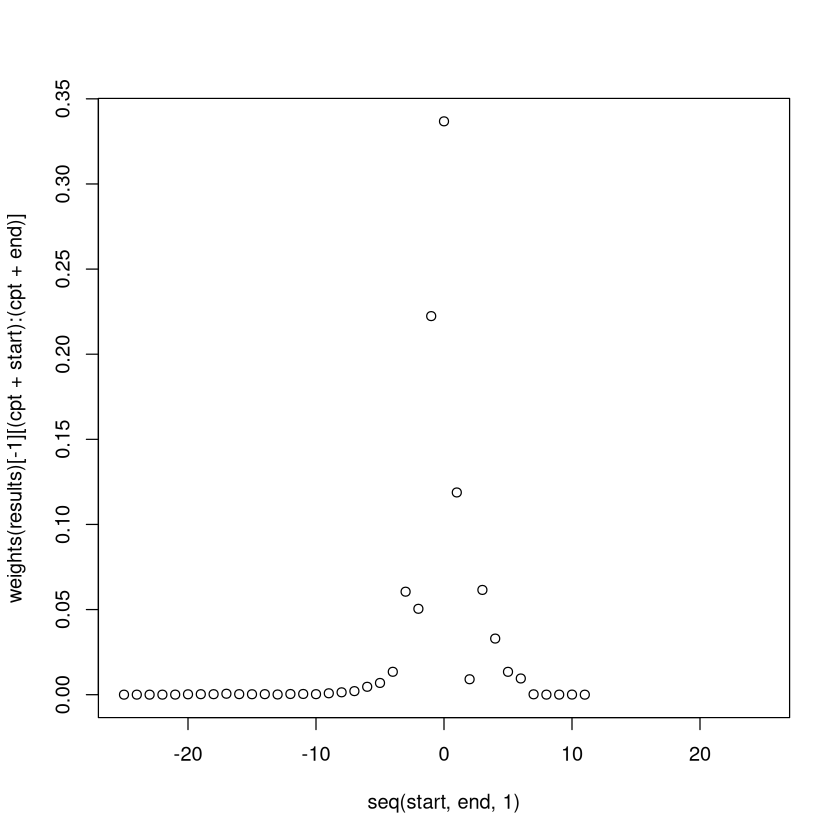

In [18]:
cpt = changepoint(results)$location
start <- -25
end <- 25
plot(seq(start,end,1),weights(results)[-1][(cpt+start):(cpt+end)])

#### Offline analysis - unknown variance

In [19]:
results <- bagel_offline(feature_vector,prior,p0,p,max_particles,threshold,Y)

#### Check for a changepoint

In [20]:
changepoint(results)

$location
[1] 501

$detected
[1] 512

#### Visualise weight at tau = 0

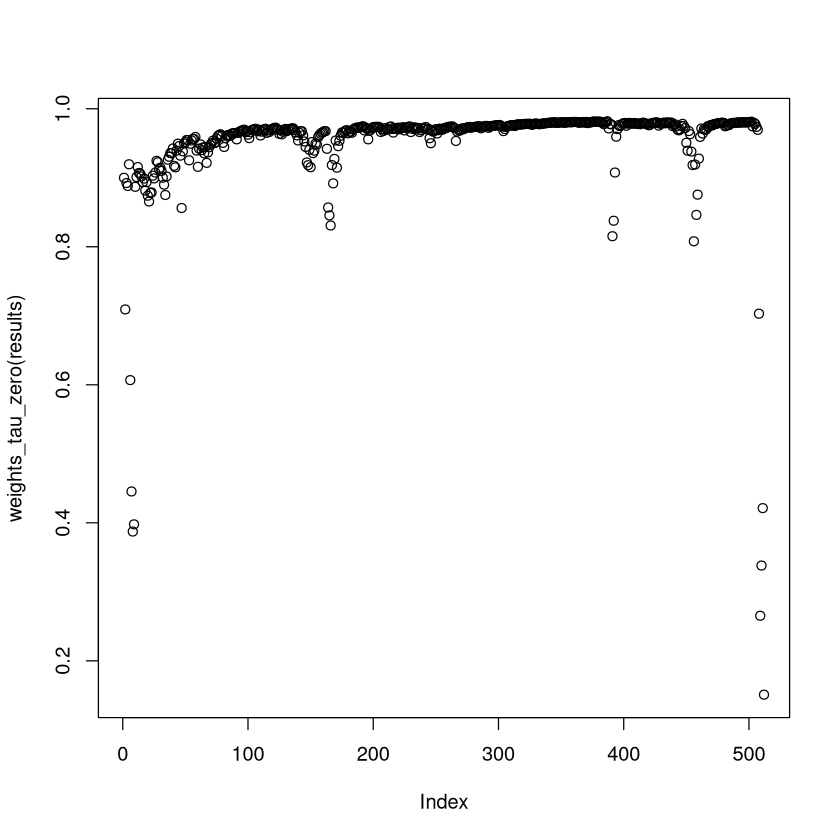

In [21]:
plot(weights_tau_zero(results))

#### Plot weights in region of changepoint

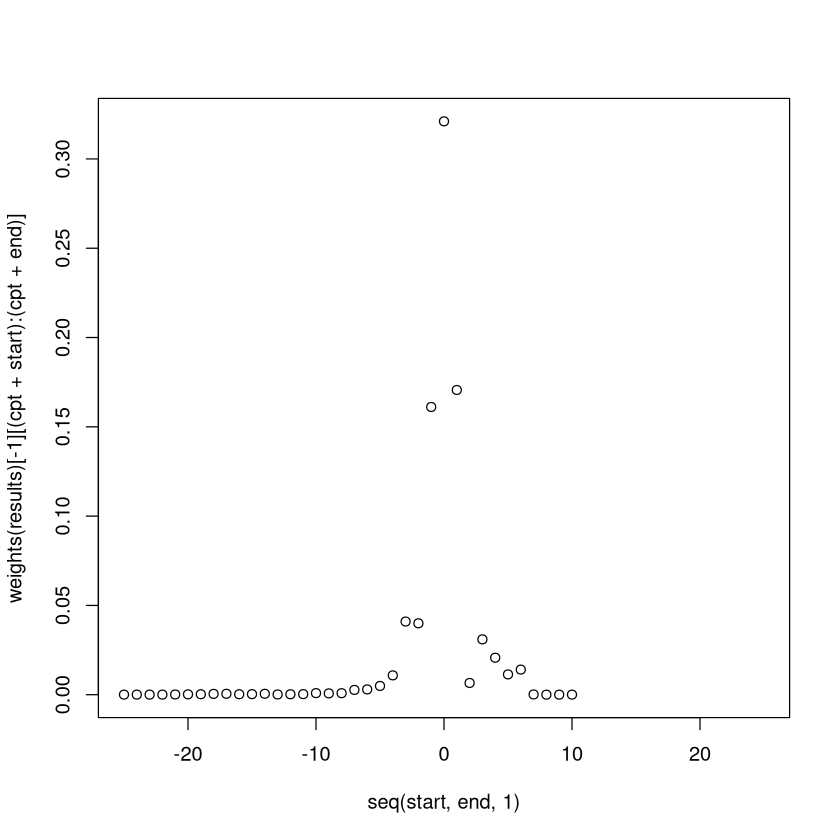

In [22]:
cpt = changepoint(results)$location
start <- -25
end <- 25
plot(seq(start,end,1),weights(results)[-1][(cpt+start):(cpt+end)])

### Example 3 - single change in mean different prior

#### Define new prior

In [23]:
prior <- function(t)
{
  mu1<-1;
  delta1<-1
  if(t == 1)
  {
    mu <- matrix(c(mu1),nc=1,nr=1)
    sigma <- delta1*diag(1)
    return(list("mu" = mu,"sigma" = sigma))
  }
  mu <- matrix(c(mu1,0),nc=1,nr=2)
  sigma <- delta1*matrix(c(1,-1,-1,2),nr=2,nc=2)
  return(list("mu" = mu,"sigma" = sigma))
}

#### Offline analysis - known variance

In [24]:
results <- bagel_offline(feature_vector,prior,p0,p,max_particles,threshold,Y,noise_sd)

#### Check for a changepoint

In [25]:
changepoint(results)

$location
[1] 501

$detected
[1] 509

#### Visualise weight at tau = 0

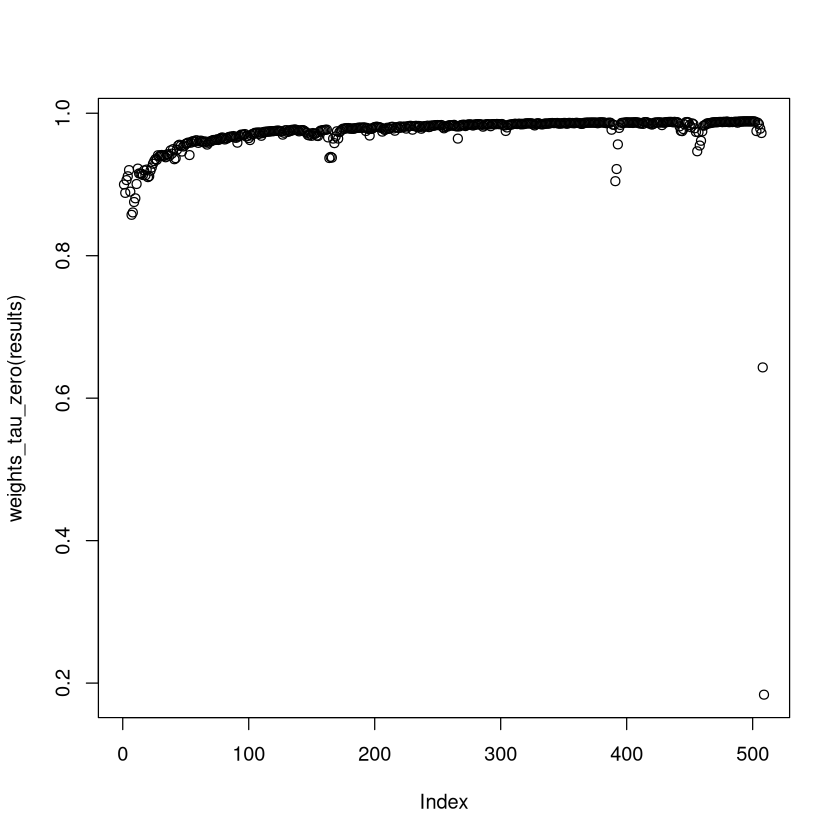

In [26]:
plot(weights_tau_zero(results))

#### Plot weights in region of changepoint

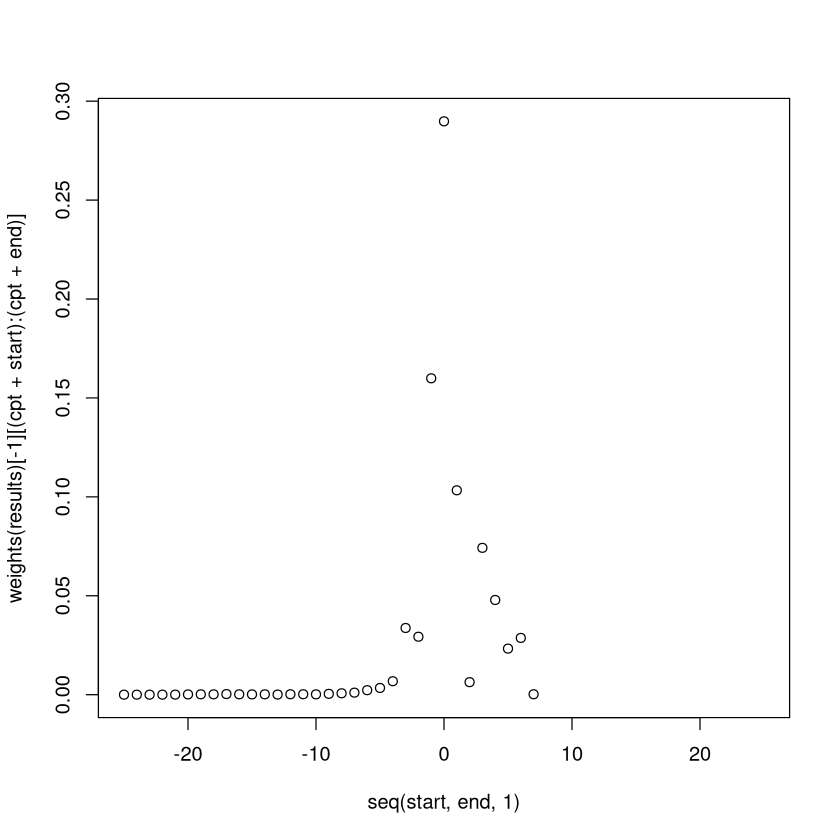

In [27]:
cpt = changepoint(results)$location
start <- -25
end <- 25
plot(seq(start,end,1),weights(results)[-1][(cpt+start):(cpt+end)])

#### Offline analysis - unknown variance

In [28]:
results <- bagel_offline(feature_vector,prior,p0,p,max_particles,threshold,Y)

#### Check for a changepoint

In [29]:
changepoint(results)

$location
[1] 501

$detected
[1] 509

#### Visualise weight at tau = 0

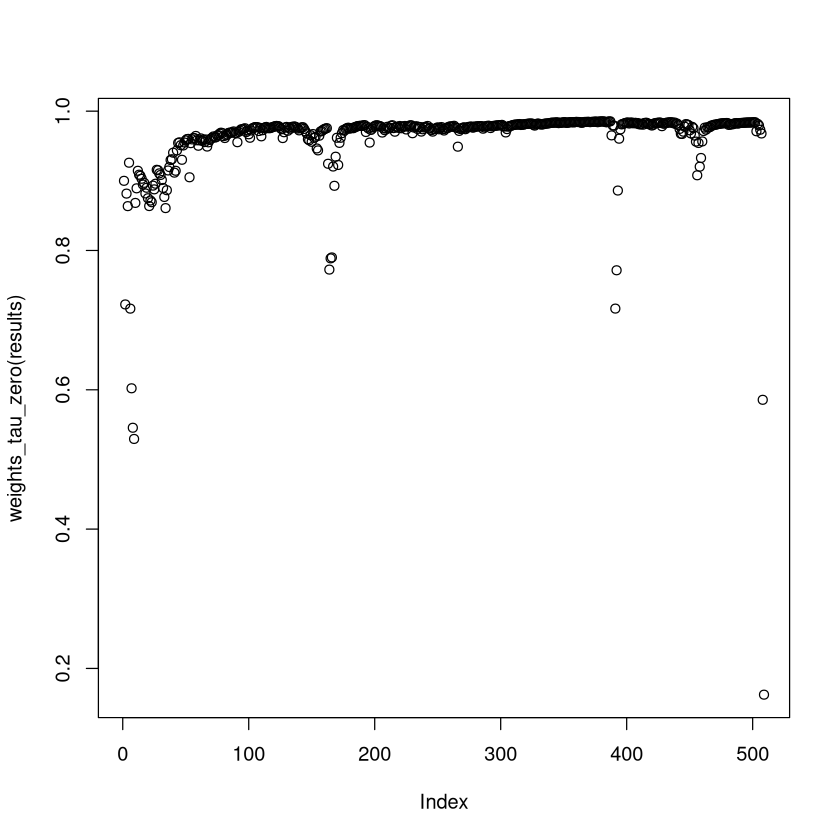

In [30]:
plot(weights_tau_zero(results))

#### Plot weights in region of changepoint

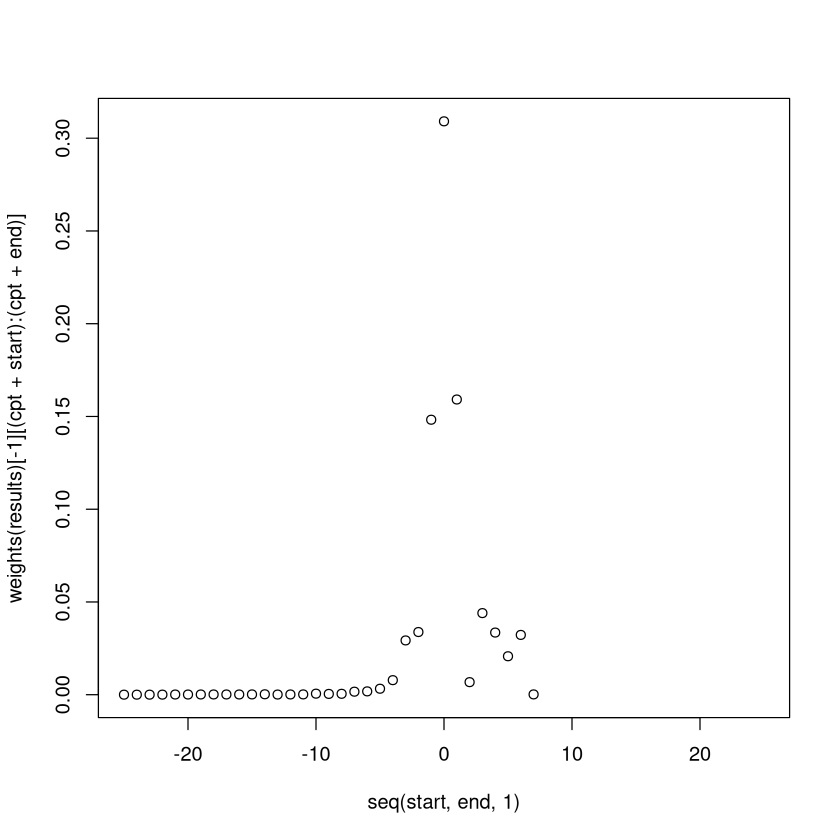

In [31]:
cpt = changepoint(results)$location
start <- -25
end <- 25
plot(seq(start,end,1),weights(results)[-1][(cpt+start):(cpt+end)])

## Using bagelR - 2 : Detecting Change in Slope

### Example 1 - no change

#### Generate some data - no change

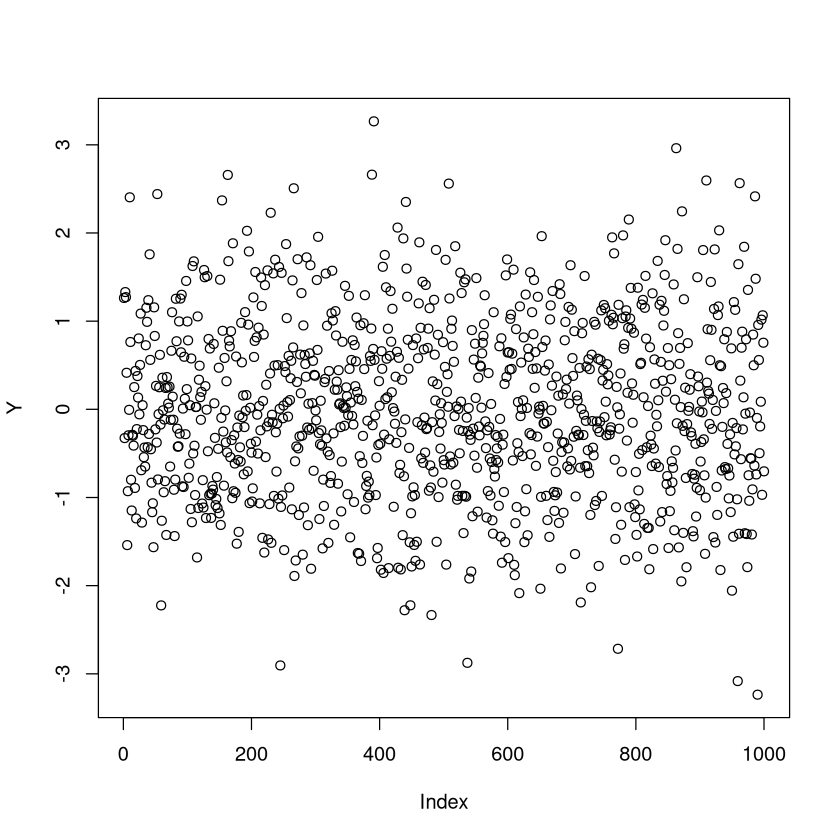

In [32]:
set.seed(0)
Y <- rnorm(1000,0,1)
plot(Y)

#### Define the feature vector function 

These functions for the **feature vector** and the **prior** correspeond to example 2 in "**Bagel : A Fast Baysian Online Changepoint Detection Algorithm for Linear Models**" *Fearnhead et al.*

In [33]:
feature_vector <- function(t,tau)
{
  if(tau == 0)
  {
     M <- matrix(c(0),nc=1,nr=2)	  
     M[1,1] <- 1
     M[2,1] <- t
     return(M)
  }
  else
  {
    M <- matrix(c(0),nc=1,nr=4)	  
    M[1,1] <- 1
    M[2,1] <- t
    if(t > tau)
    {
      M[3,1] <- 1
      M[4,1] <- t
    }
  return(M)
  }
}

#### Define the prior function

In [34]:
prior <- function(t)
{
  if(t == 1)
  {
     mu <- matrix(c(0),nc=1,nr=2)
     sigma <- diag(2)
     return(list("mu" = mu,"sigma" = sigma))
  }
  mu <- matrix(c(0),nc=1,nr=4)
  sigma <- diag(4)
  sigma[3,3] <- (t-1)*(t-1)
  sigma[4,3] <- sigma[3,4] <- -(t-1)
  return(list("mu" = mu,"sigma" = sigma))
}

#### Set model parameters 

In [35]:
p <- 1.0;
p0 <- 0.9;
noise_sd <- 1.0;
max_particles <- 250
threshold <- 0.8

#### Offline analysis - known variance

In [36]:
results <- bagel_offline(feature_vector,prior,p0,p,max_particles,threshold,Y,noise_sd)

#### Check for a changepoint

In [37]:
changepoint(results)

[1] NA

#### Visualise weight at tau = 0

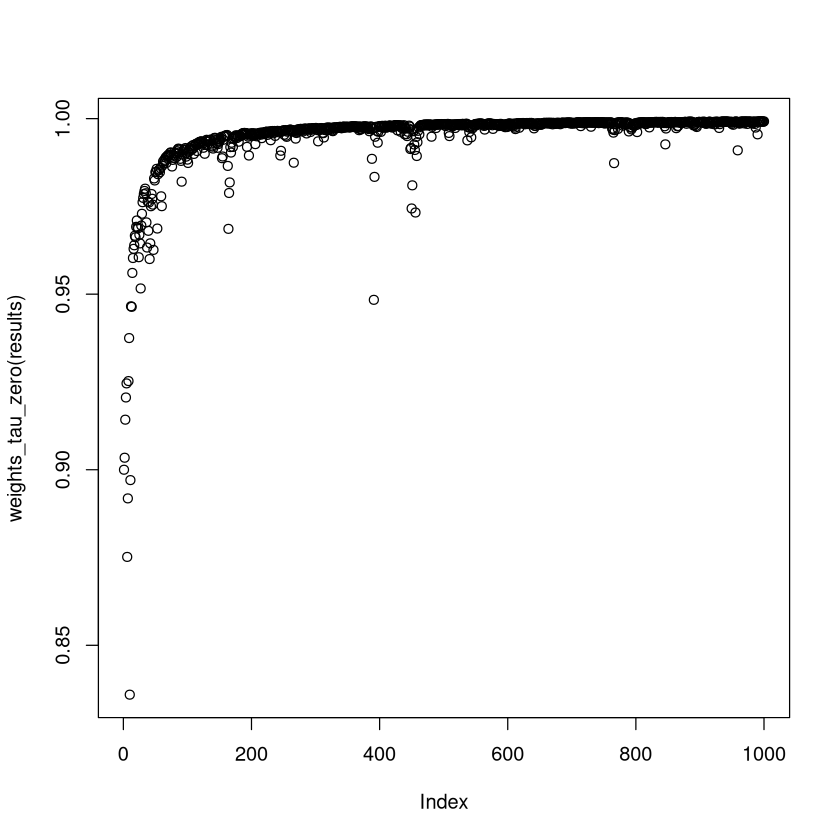

In [38]:
plot(weights_tau_zero(results))

#### Offline analysis - unknown variance

In [39]:
results <- bagel_offline(feature_vector,prior,p0,p,max_particles,threshold,Y)

#### Check for a changepoint

In [40]:
changepoint(results)

[1] NA

#### Visualise weight at tau = 0

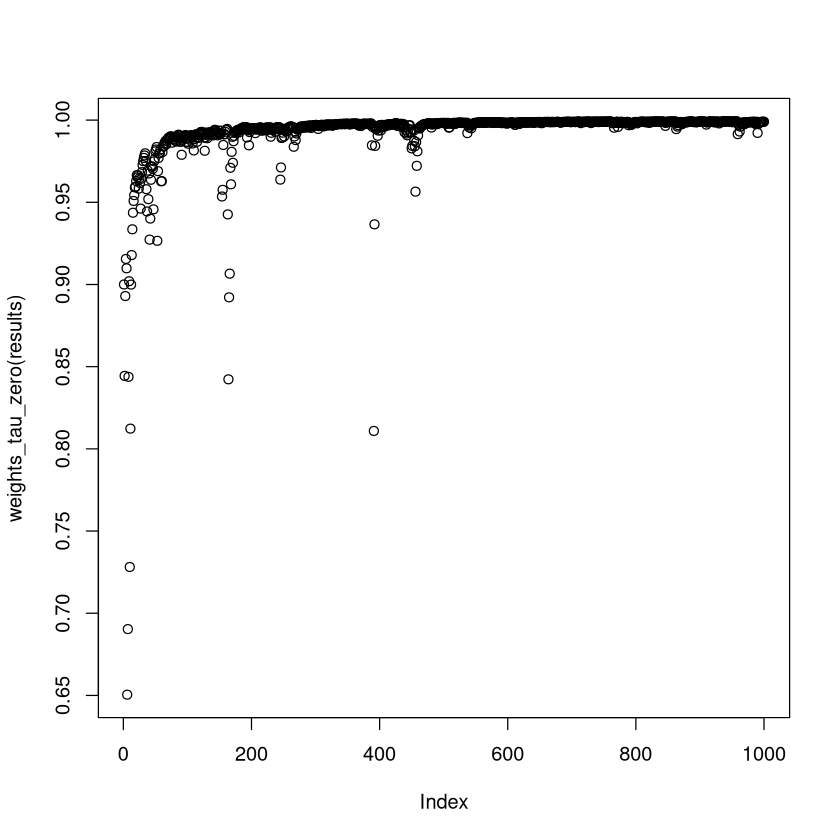

In [41]:
plot(weights_tau_zero(results))

### Example 2 - single change in slope

#### Generate data with change in slope at t = 1000

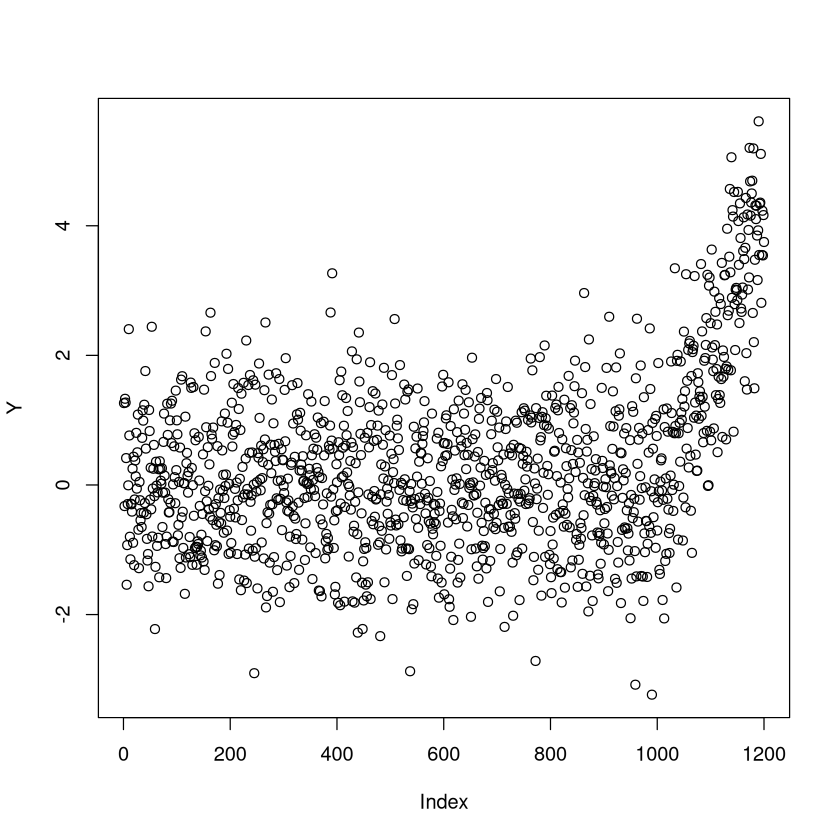

In [42]:
set.seed(0)
Y <- c(rnorm(1000,0,1),seq(1,200,1)/50 + rnorm(200,0,1))
plot(Y)

#### Offline analysis - known variance

In [43]:
results <- bagel_offline(feature_vector,prior,p0,p,max_particles,threshold,Y,noise_sd)

#### Check for a changepoint

In [44]:
changepoint(results)

$location
[1] 1021

$detected
[1] 1058

#### Visualise weight at tau = 0

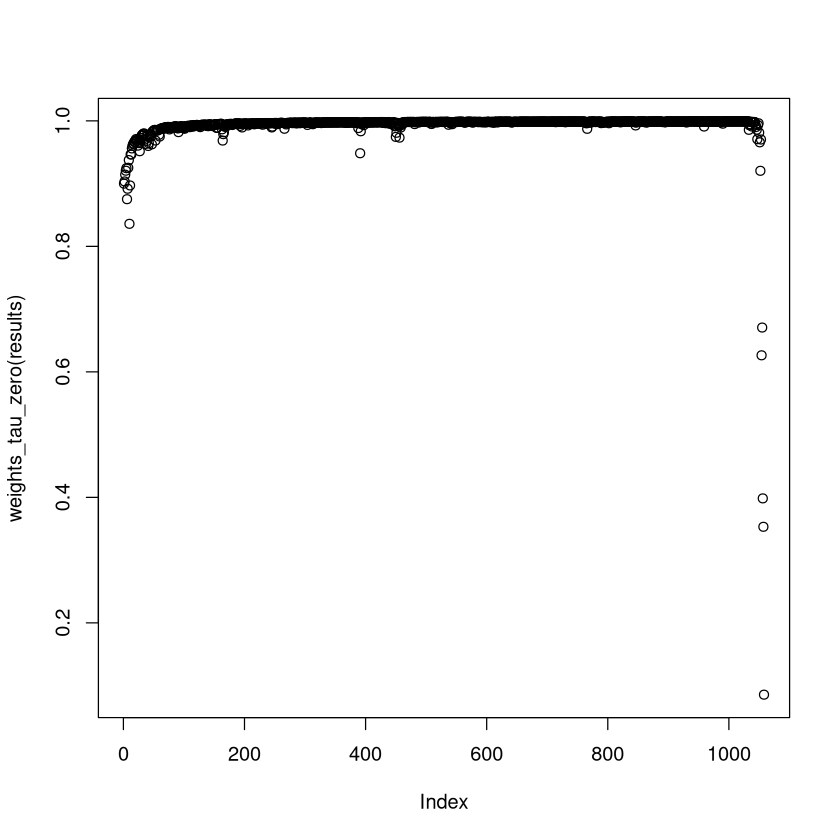

In [45]:
plot(weights_tau_zero(results))

#### Plot weights in region of changepoint

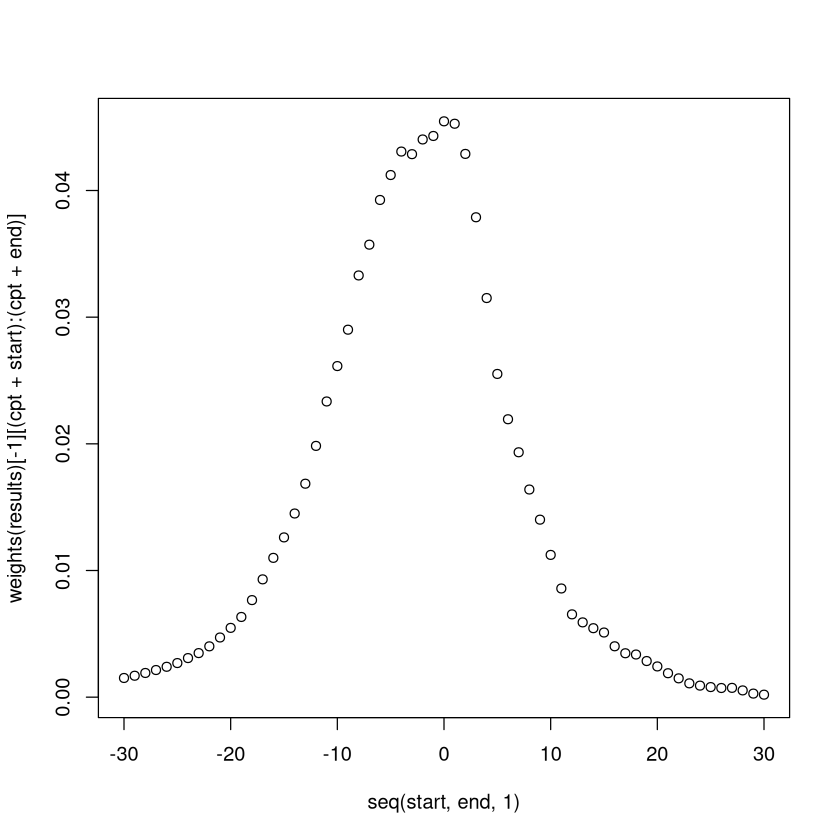

In [46]:
cpt = changepoint(results)$location
start <- -30
end <- 30
plot(seq(start,end,1),weights(results)[-1][(cpt+start):(cpt+end)])

#### Offline analysis - unknown variance

In [47]:
results <- bagel_offline(feature_vector,prior,p0,p,max_particles,threshold,Y)

#### Check for a changepoint

In [48]:
changepoint(results)

$location
[1] 1032

$detected
[1] 1058

#### Visualise weight at tau = 0

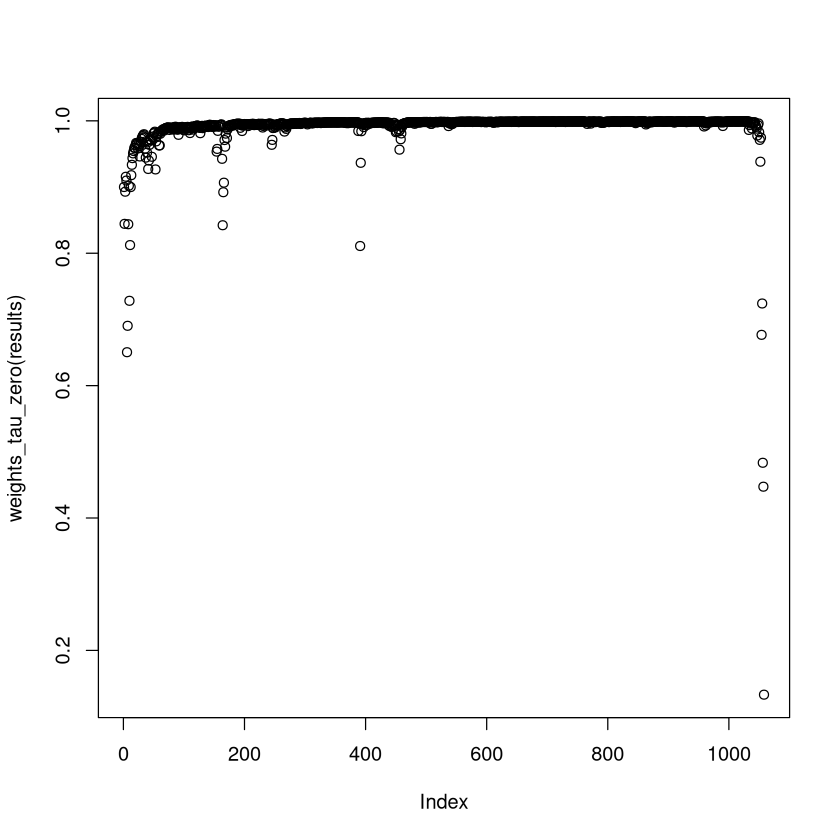

In [49]:
plot(weights_tau_zero(results))

#### Plot weights in region of changepoint

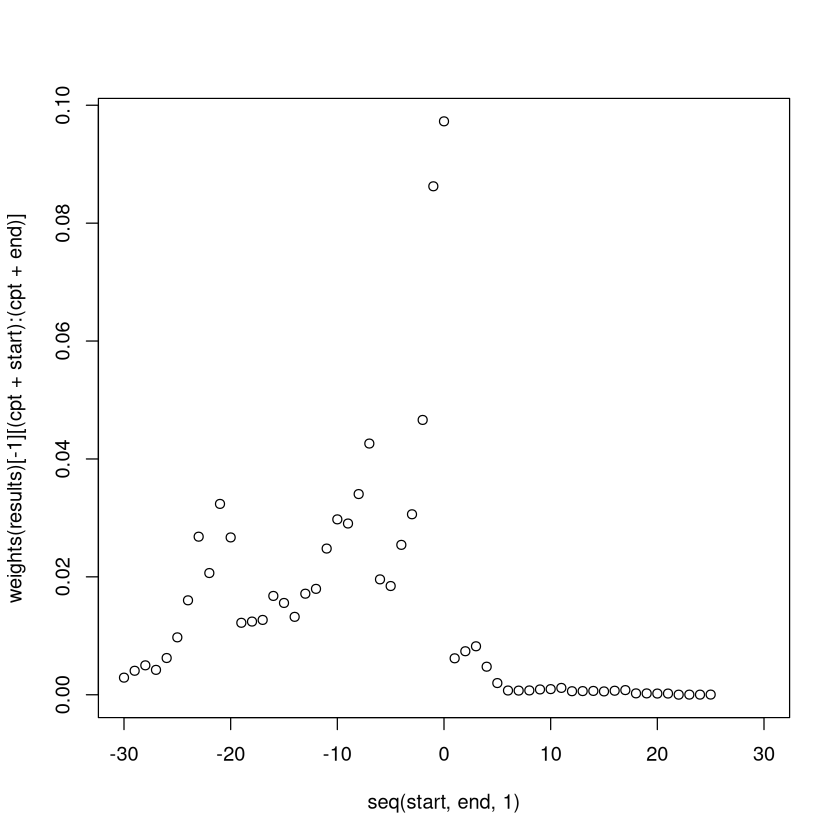

In [50]:
cpt = changepoint(results)$location
start <- -30
end <- 30
plot(seq(start,end,1),weights(results)[-1][(cpt+start):(cpt+end)])

### Other methods

### Get the taus

- Returns a vector of tau values for the active (unpruned) particles

In [51]:
taus(results)

[1]    0    1    2    3    4    5    6    7    8    9   10   11   14   16   18
 [16]   21   22   23   24   25   26   27   28   30   31   32   33   34   35   36
 [31]   37   38   39   40   42   43   44   45   46   47   49   50   51   52   56
 [46]   58   70   74   79   86   97  101  103  104  105  106  107  109  113  118
 [61]  122  123  124  125  128  135  142  146  147  148  149  150  151  152  153
 [76]  158  160  161  162  185  191  204  211  213  214  218  222  224  227  229
 [91]  235  240  241  242  243  244  263  265  357  365  372  380  382  384  385
[106]  386  387  389  390  403  411  424  426  427  432  434  435  436  438  453
[121]  560  608  725  759  764  767  771  781  804  816  828  835  844  852  856
[136]  858  859  861  862  870  893  901  903  906  907  913  918  920  921  922
[151]  925  928  935  943  944  945  946  947  948  949  950  951  952  953  954
[166]  955  956  957  958  959  960  961  965  967  968  971  972  973  976  978
[181]  979  980  981  982  983  984  985  986  987  988  989  993  995  997  999
[196] 1000 1001 1003 1006 1007 1008 1009 1010 1011 1012 1013 1014 1015 1016 1017
[211] 1018 1019 1020 1021 1022 1023 1024 1025 1026 1027 1028 1029 1030 1031 1032
[226] 1033 1034 1035 1036 1037 1038 1039 1040 1041 1042 1043 1044 1045 1046 1047
[241] 1048 1049 1050 1051 1052 1053 1054 1055 1056 1057

### Get the ratios

- Returns a list of vectors containing the ratios for each active (unpruned) particle

In [52]:
ratios <- ratios(results)
ratios[[44]]

[1] 1

### Get weights of active particles

- Returns a vector of weights for the currently active (unpruned) particles

In [53]:
active_weights(results)

[1] 1.331262e-01 1.170990e-05 7.147224e-06 6.103670e-06 8.124853e-06
  [6] 6.387828e-06 1.272048e-06 1.430928e-06 2.051882e-06 1.408071e-06
 [11] 1.833418e-07 1.586094e-07 2.584128e-07 1.767171e-07 1.957770e-07
 [16] 2.844720e-07 1.281634e-07 1.567783e-07 1.409488e-07 1.909725e-07
 [21] 1.922704e-07 1.278268e-07 1.261262e-07 1.979295e-07 1.470011e-07
 [26] 1.964831e-07 2.888924e-07 4.364835e-07 4.833493e-07 3.218738e-07
 [31] 2.933660e-07 3.743099e-07 2.688533e-07 3.026249e-07 2.200891e-07
 [36] 2.005491e-07 2.613818e-07 2.614985e-07 2.370924e-07 1.262624e-07
 [41] 1.976724e-07 1.700579e-07 2.786509e-07 2.718289e-07 1.403224e-07
 [46] 1.347740e-07 1.646951e-07 1.295163e-07 2.487766e-07 2.588480e-07
 [51] 5.460948e-07 2.574678e-07 2.289491e-07 2.305440e-07 2.179845e-07
 [56] 2.913193e-07 1.716766e-07 1.636542e-07 1.996755e-07 2.082445e-07
 [61] 2.937356e-07 1.437729e-07 1.702236e-07 1.392659e-07 1.424470e-07
 [66] 1.872051e-07 1.787496e-07 2.936765e-07 1.287185e-07 2.334172e-07
 [71] 3.501284e-07 3.349798e-07 1.642636e-07 1.556309e-07 2.118757e-07
 [76] 1.314970e-07 1.725833e-07 2.067232e-07 2.633457e-07 2.574503e-07
 [81] 2.130996e-07 3.447404e-07 1.964281e-07 1.580188e-07 1.297471e-07
 [86] 3.190530e-07 2.351133e-07 2.312966e-07 2.449384e-07 2.762340e-07
 [91] 1.892608e-07 2.430490e-07 1.653549e-07 1.931173e-07 1.399568e-07
 [96] 1.999315e-07 3.370056e-07 1.608239e-07 3.664962e-07 1.800582e-07
[101] 1.849513e-07 2.718886e-07 1.521667e-07 2.074070e-07 2.106697e-07
[106] 4.697608e-07 6.521829e-07 3.644030e-07 2.541868e-07 3.249438e-07
[111] 1.615450e-07 2.570032e-07 2.702148e-07 2.263746e-07 4.239206e-07
[116] 2.832211e-07 3.304286e-07 2.587510e-07 2.890867e-07 2.740492e-07
[121] 8.441011e-07 6.175989e-07 1.002429e-06 8.446102e-07 1.125413e-06
[126] 4.882680e-07 1.005319e-06 8.406075e-07 1.630748e-06 8.942996e-07
[131] 8.842524e-07 9.385400e-07 2.191205e-06 1.865736e-06 1.902022e-06
[136] 2.677957e-06 1.327267e-06 4.030158e-06 3.367800e-06 4.934822e-06
[141] 5.799708e-06 5.408378e-06 4.874664e-06 1.075648e-05 5.403587e-06
[146] 9.810774e-06 1.449433e-05 1.620452e-05 8.163189e-06 7.854478e-06
[151] 1.167856e-05 1.752801e-05 2.436800e-05 9.197395e-05 3.335697e-05
[156] 4.545251e-05 7.353822e-05 1.318858e-04 1.713856e-04 2.262772e-04
[161] 1.294535e-04 2.161182e-04 1.916064e-04 2.171019e-04 3.735853e-04
[166] 4.941696e-04 1.197340e-03 3.313949e-03 4.272122e-03 3.739739e-04
[171] 2.679388e-04 1.751140e-04 2.820786e-04 3.903418e-04 3.583117e-04
[176] 7.262848e-04 4.097030e-04 3.846917e-04 6.800299e-04 7.885920e-04
[181] 7.957155e-04 1.272257e-03 1.236232e-03 1.713342e-03 2.732696e-03
[186] 5.206333e-03 7.793092e-03 2.354185e-03 2.121260e-03 4.096562e-03
[191] 4.964446e-03 1.750036e-03 2.312854e-03 3.297439e-03 4.533913e-03
[196] 3.666986e-03 5.079095e-03 6.970484e-03 1.544309e-02 9.736483e-03
[201] 1.601953e-02 2.681434e-02 2.064706e-02 3.237412e-02 2.668742e-02
[206] 1.220748e-02 1.241548e-02 1.269399e-02 1.676380e-02 1.557094e-02
[211] 1.321488e-02 1.714187e-02 1.796138e-02 2.480041e-02 2.975231e-02
[216] 2.904922e-02 3.404448e-02 4.261368e-02 1.957234e-02 1.844420e-02
[221] 2.542619e-02 3.061475e-02 4.662014e-02 8.625367e-02 9.727286e-02
[226] 6.181634e-03 7.380400e-03 8.221002e-03 4.758753e-03 1.982492e-03
[231] 7.193768e-04 7.046296e-04 7.298782e-04 8.996585e-04 9.547935e-04
[236] 1.160671e-03 5.992003e-04 6.198772e-04 6.490508e-04 5.651587e-04
[241] 6.819498e-04 7.885812e-04 2.350489e-04 2.284363e-04 2.055840e-04
[246] 2.045655e-04 1.402241e-05 2.172699e-05 1.993626e-05 3.061531e-05